In [1]:
from datasets import load_dataset
import os
import pandas as pd
import cv2
import numpy as np
from tqdm import tqdm
import random
import gc
import matplotlib.pyplot as plt

c:\Users\USER\miniconda3\envs\accident_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_dataset("nexar-ai/nexar_collision_prediction", split="train")

print(dataset.column_names, '\n')
print("train length", len(dataset))

['video', 'time_of_event', 'time_of_alert', 'light_conditions', 'weather', 'scene', 'time_to_accident'] 

train length 1500


In [4]:
train_meta = pd.read_pickle("train_meta_processed.pkl")

### Frame Generator

In [5]:
def video_batch_generator(meta_df, batch_size=4, num_frames=24, total_window=10, target_size=(224, 224)):
    n = len(meta_df)
    for start_idx in range(0, n, batch_size):
        batch_meta = meta_df.iloc[start_idx : start_idx + batch_size]
        batch_videos = []
        batch_labels = []
        batch_metadata = []
        skipped_video_counter=0

        for _, row in batch_meta.iterrows():
            video_path = os.path.join(row["folder"], row["file_name"])
            time_of_event = row["time_of_event"]
            time_of_alert = row["time_of_alert"]

            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                print(f"Skipping unreadable video: {video_path}")
                skipped_video_counter+=1
                continue

            fps = cap.get(cv2.CAP_PROP_FPS)
            n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            duration = n_frames / fps

            if time_of_event is not None and not np.isnan(time_of_event):
                min_start = max(0, time_of_alert - (total_window - (time_of_event - time_of_alert)) - 0.5)
                max_start = max(0, min(time_of_alert - 0.1, time_of_event - 1.0))

                start_time = random.uniform(min_start, max_start) if max_start > min_start else min_start
                end_time = start_time + total_window

                if end_time > duration:
                    end_time = duration
                    start_time = max(0, end_time - total_window)

            else:
                if duration <= total_window:
                    start_time = 0
                    end_time = duration
                else:
                    start_time = random.uniform(0, duration - total_window)
                    end_time = start_time + total_window


            start_frame = int(start_time * fps)
            end_frame = int(end_time * fps)

            selected_frames = np.linspace(start_frame, end_frame - 1, num_frames, dtype=int)

            frames = []
            cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
            current_idx = start_frame
            flag, frame = cap.read()

            while flag and current_idx <= end_frame:
                if current_idx in selected_frames:
                    frame = cv2.resize(frame, target_size)
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frames.append(frame)
                    if len(frames) == num_frames:
                        break
                flag, frame = cap.read()
                current_idx += 1

            cap.release()

            if len(frames) != num_frames:
                print(f"Skipping {video_path} (got only {len(frames)} frames)")
                continue

            batch_videos.append(np.array(frames))
            batch_labels.append(int(row["label"])) 
            batch_metadata.append(row.to_dict())

        if batch_videos:
            yield np.array(batch_videos), np.array(batch_labels, dtype=np.int8), batch_metadata

In [6]:
train_gen = video_batch_generator(train_meta, batch_size=4)

training_data = []

for X_batch, y_batch, batch_metadata in tqdm(train_gen, total=len(train_meta)//4+1, desc="Extracting videos"):
    for i in range(len(X_batch)):
        row = {
            "Frames": X_batch[i],
            "Label": y_batch[i],
            "light_conditions": batch_metadata[i]["light_conditions"],
            "weather_cloudy": batch_metadata[i]["weather_cloudy"],
            "weather_rain": batch_metadata[i]["weather_rain"],
            "scene_highway": batch_metadata[i]["scene_highway"],
            "scene_rural": batch_metadata[i]["scene_rural"]}
        
        training_data.append(row)

train_table = pd.DataFrame(training_data)

print(train_table.head())
print("Number of videos:", len(train_table))
print("Example frame shape:", train_table.iloc[0]["Frames"].shape)


Extracting videos: 100%|█████████▉| 375/376 [39:36<00:06,  6.34s/it]


                                              Frames  Label  light_conditions  \
0  [[[[ 93 171 223], [ 88 165 218], [ 90 167 220]...      1                 0   
1  [[[[251 251 251], [251 251 251], [251 251 251]...      1                 0   
2  [[[[27 27 23], [26 26 21], [26 26 21], [26 26 ...      1                 0   
3  [[[[65 55 57], [76 62 67], [60 50 55], [119 11...      1                 0   
4  [[[[3 6 0], [3 5 5], [5 5 5], [6 4 5], [5 3 0]...      1                 0   

   weather_cloudy  weather_rain  scene_highway  scene_rural  
0               1             0              0            0  
1               1             0              0            0  
2               0             0              0            0  
3               0             0              0            0  
4               0             0              1            0  
Number of videos: 1500
Example frame shape: (24, 224, 224, 3)



--- Positive (Label 1) ---
Label: 1
Metadata: {'light_conditions': 0, 'weather_cloudy': 1, 'weather_rain': 0, 'scene_highway': 0, 'scene_rural': 0}


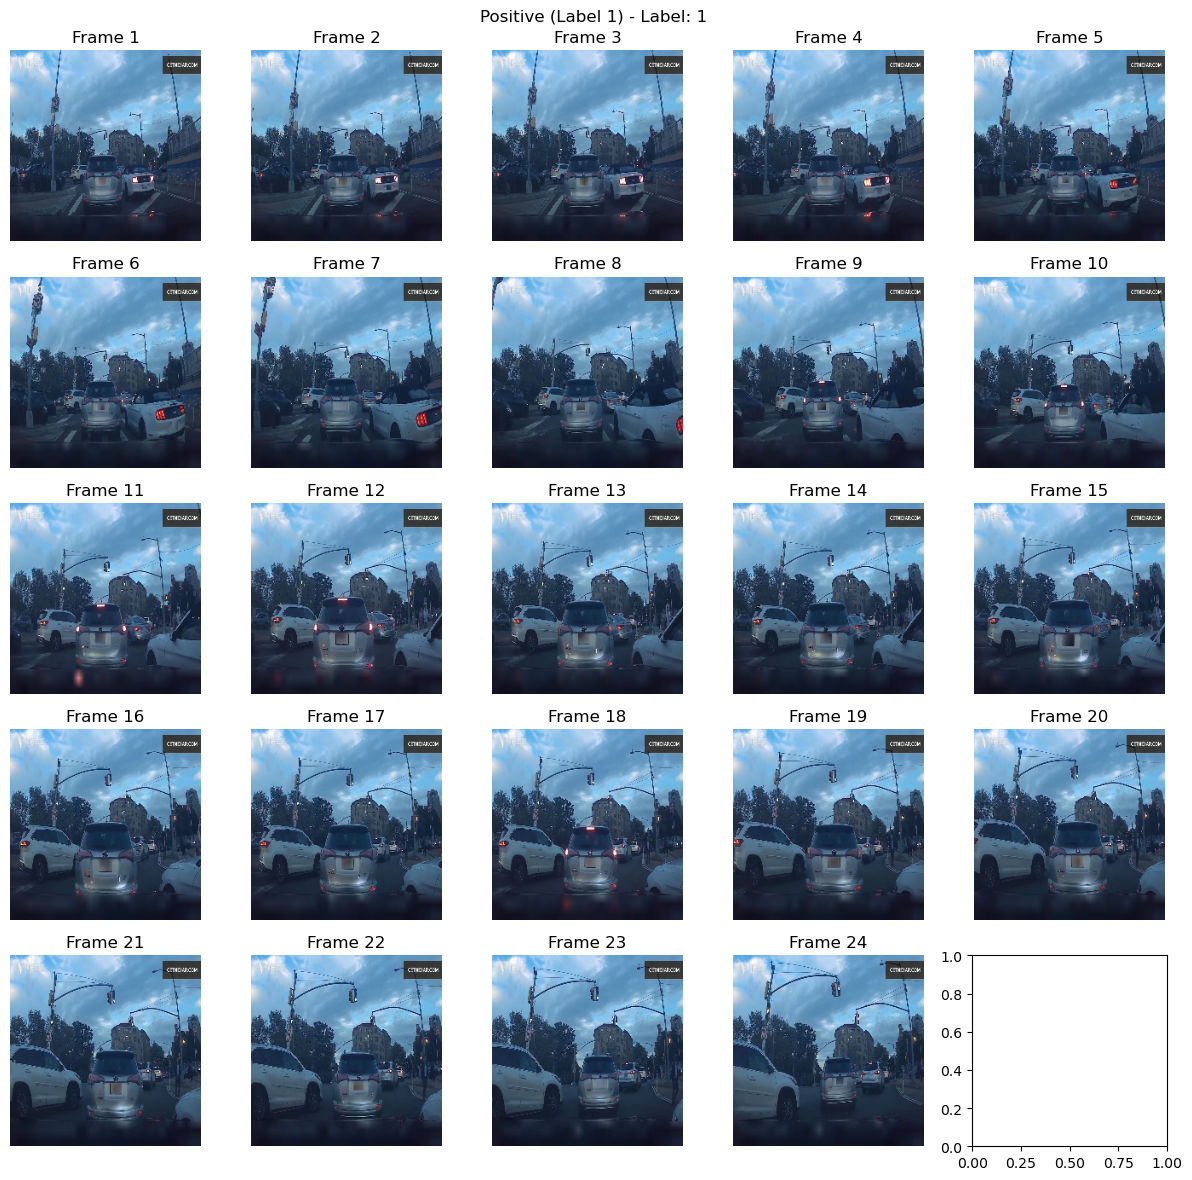


--- Negative (Label 0) ---
Label: 0
Metadata: {'light_conditions': 0, 'weather_cloudy': 0, 'weather_rain': 0, 'scene_highway': 0, 'scene_rural': 0}


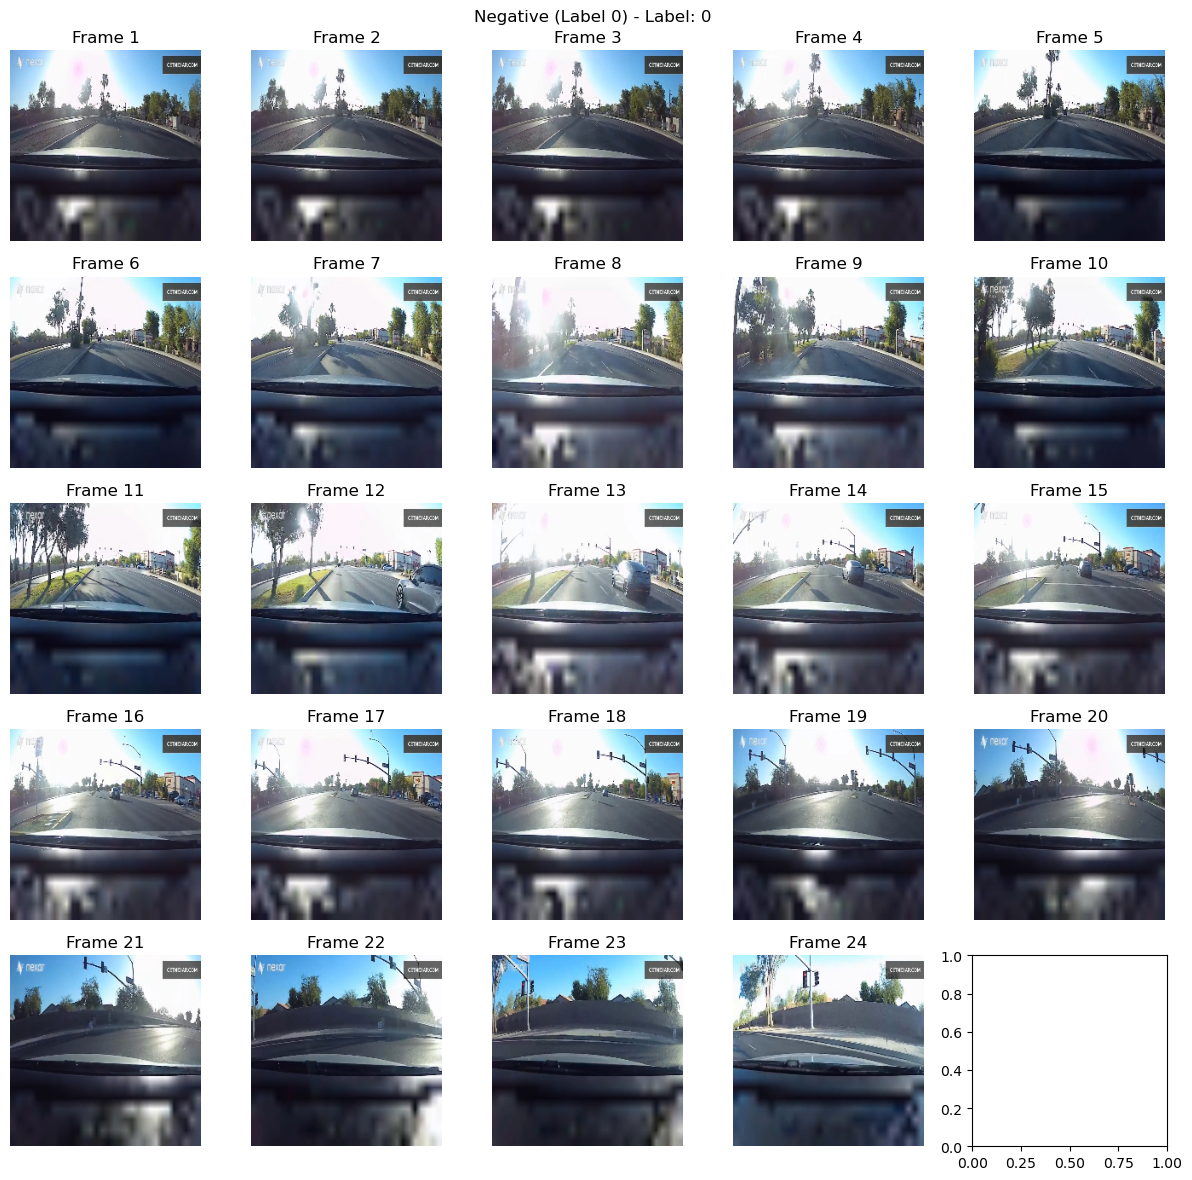

0

In [8]:
import gc
import matplotlib.pyplot as plt
import numpy as np

sample_pos = train_table[train_table["Label"] == 1].iloc[0]
sample_neg = train_table[train_table["Label"] == 0].iloc[0]

samples = [("Positive (Label 1)", sample_pos), ("Negative (Label 0)", sample_neg)]

for title, sample in samples:
    video_frames = sample["Frames"]
    label = sample["Label"]
    train_meta = sample[["light_conditions", "weather_cloudy", "weather_rain", "scene_highway", "scene_rural"]].to_dict()

    print(f"\n--- {title} ---")
    print("Label:", label)
    print("Metadata:", train_meta)

    fig, axes = plt.subplots(5, 5, figsize=(12, 12))
    axes = axes.flatten()

    for i in range(24):
        axes[i].imshow(video_frames[i].astype(np.uint8))
        axes[i].axis("off")
        axes[i].set_title(f"Frame {i+1}")

    plt.suptitle(f"{title} - Label: {label}")
    plt.tight_layout()
    plt.show()

    plt.close(fig)

    del video_frames
    gc.collect()

del samples, sample_pos, sample_neg
gc.collect()



In [9]:
train_table.to_pickle("train_table.pkl")

### Test Data

In [11]:
test_meta = pd.read_pickle("test_meta_processed.pkl")

In [12]:
test_gen = video_batch_generator(test_meta, batch_size=4)

test_data = []

for X_batch, y_batch, batch_metadata in tqdm(test_gen, total=len(test_meta)//4+1, desc="Extracting videos"):
    for i in range(len(X_batch)):
        row = {
            "Frames": X_batch[i],
            "Label": y_batch[i],
            "light_conditions": batch_metadata[i]["light_conditions"],
            "weather_cloudy": batch_metadata[i]["weather_cloudy"],
            "weather_rain": batch_metadata[i]["weather_rain"],
            "scene_highway": batch_metadata[i]["scene_highway"],
            "scene_rural": batch_metadata[i]["scene_rural"]}
        
        test_data.append(row)

test_table = pd.DataFrame(test_data)

print(test_table.head())
print("Number of videos:", len(test_table))
print("Example frame shape:", test_table.iloc[0]["Frames"].shape)


Extracting videos: 100%|█████████▉| 336/337 [36:00<00:06,  6.43s/it] 


                                              Frames  Label  light_conditions  \
0  [[[[22 10 10], [29 20 17], [24  9  3], [21  8 ...      1                 0   
1  [[[[75 86 92], [75 86 92], [75 86 90], [77 89 ...      1                 0   
2  [[[[66 71 70], [66 71 70], [66 72 71], [63 77 ...      1                 0   
3  [[[[169 238 255], [173 228 252], [139 185 208]...      1                 0   
4  [[[[27 24 36], [27 24 36], [27 24 36], [29 24 ...      1                 0   

   weather_cloudy  weather_rain  scene_highway  scene_rural  
0               0             0              0            0  
1               0             1              1            0  
2               0             1              0            1  
3               0             0              0            0  
4               1             0              0            0  
Number of videos: 1344
Example frame shape: (24, 224, 224, 3)


In [13]:
test_table.to_pickle("test_table.pkl")